In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from itertools import count

from node_b import NodeB
from anothermultiwrapper import MultiGNBWrapper

from slice_l1 import SliceL1eMBB
from slice_ran import SliceRANeMBB
from channel_models import SINRSelectiveFading, MCSCodeset
from schedulers import ProportionalFair

In [3]:
rng = default_rng(42)

N_GNBS = 20
N_UES = 30

slots_per_step = 50
slot_length = 1e-3
n_prbs = 100
coverage_radius = 220

CBR_description = {
    'lambda': 2.0 / 60.0,
    't_mean': 30.0,
    'bit_rate': 500000
}

VBR_description = {
    'lambda': 5.0 / 60.0,
    't_mean': 30.0,
    'p_size': 1000,
    'b_size': 500,
    'b_rate': 1
}

SLA_embb = {
    'cbr_th': 10e6,
    'cbr_prb': 20,
    'cbr_queue': 10e4,
    'vbr_th': 15e6,
    'vbr_prb': 30,
    'vbr_queue': 15e4
}

state_variables_embb = [
    'cbr_traffic', 'cbr_th', 'cbr_prb', 'cbr_queue', 'cbr_snr',
    'vbr_traffic', 'vbr_th', 'vbr_prb', 'vbr_queue', 'vbr_snr'
]

time_per_step = slots_per_step * slot_length
norm_const_embb = {
    'cbr_traffic': 5e6 * time_per_step,
    'cbr_th': 10e6 * time_per_step,
    'cbr_prb': 25 * slots_per_step,
    'cbr_queue': 10e4 * slots_per_step,
    'cbr_snr': 35 * slots_per_step,
    'vbr_traffic': 5e6 * time_per_step,
    'vbr_th': 10e6 * time_per_step,
    'vbr_prb': 35 * slots_per_step,
    'vbr_queue': 10e4 * slots_per_step,
    'vbr_snr': 35 * slots_per_step
}

In [4]:
def build_gnb(gnb_id, x, y, carrier_id):
    snr_generator = SINRSelectiveFading(rng, 'macro_cell_urban_2GHz', n_prbs=n_prbs)
    mcs_codeset = MCSCodeset()
    scheduler = ProportionalFair(mcs_codeset)
    user_counter = count(gnb_id * 10000)

    slice_ran = SliceRANeMBB(
        rng=rng,
        user_counter=user_counter,
        id=0,
        SLA=SLA_embb,
        CBR_description=CBR_description,
        VBR_description=VBR_description,
        state_variables=state_variables_embb,
        norm_const=norm_const_embb,
        slots_per_step=slots_per_step,
        slot_length=slot_length
    )

    slice_l1 = SliceL1eMBB(
        rng=rng,
        snr_generator=snr_generator,
        n_prbs=n_prbs,
        slices_ran=[slice_ran],
        scheduler=scheduler
    )

    return NodeB(
        id=gnb_id,
        x=x,
        y=y,
        slices_l1=[slice_l1],
        slots_per_step=slots_per_step,
        n_prbs=n_prbs,
        coverage_radius=coverage_radius,
        slot_length=slot_length,
        carrier_id=carrier_id,
        center_frequency_hz=3.5e9,
        bandwidth_hz=20e6,
        tx_power_dbm=30.0,
        noise_figure_db=7.0
    )

In [5]:
test_gnb = build_gnb(0, 0, 0, 0)
print("OK:", test_gnb)
print("State length:", len(test_gnb.get_state()))

OK: NodeB 0 at (0.00, 0.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
State length: 12


In [6]:
gnbs = []

grid_size = int(np.ceil(np.sqrt(N_GNBS)))
spacing = coverage_radius * 1.5

idx = 0
for i in range(grid_size):
    for j in range(grid_size):
        if idx >= N_GNBS:
            break
        x = i * spacing
        y = j * spacing
        gnbs.append(build_gnb(idx, x, y, carrier_id=idx % 3))
        idx += 1

print("Built gNBs:", len(gnbs))
for g in gnbs:
    print(g)

Built gNBs: 20
NodeB 0 at (0.00, 0.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 1 at (0.00, 330.00), radius=220, carrier_id=1, f=3.50GHz, bw=20.0MHz
NodeB 2 at (0.00, 660.00), radius=220, carrier_id=2, f=3.50GHz, bw=20.0MHz
NodeB 3 at (0.00, 990.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 4 at (0.00, 1320.00), radius=220, carrier_id=1, f=3.50GHz, bw=20.0MHz
NodeB 5 at (330.00, 0.00), radius=220, carrier_id=2, f=3.50GHz, bw=20.0MHz
NodeB 6 at (330.00, 330.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 7 at (330.00, 660.00), radius=220, carrier_id=1, f=3.50GHz, bw=20.0MHz
NodeB 8 at (330.00, 990.00), radius=220, carrier_id=2, f=3.50GHz, bw=20.0MHz
NodeB 9 at (330.00, 1320.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 10 at (660.00, 0.00), radius=220, carrier_id=1, f=3.50GHz, bw=20.0MHz
NodeB 11 at (660.00, 330.00), radius=220, carrier_id=2, f=3.50GHz, bw=20.0MHz
NodeB 12 at (660.00, 660.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.

In [7]:
# ===============================
# Heat maps for 20 gNodeB network
# ===============================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Grid limits from gNB positions
# -------------------------------
all_x = [g.x for g in gnbs]
all_y = [g.y for g in gnbs]

margin = coverage_radius * 1.5
x_min, x_max = min(all_x) - margin, max(all_x) + margin
y_min, y_max = min(all_y) - margin, max(all_y) + margin

nx, ny = 180, 180
xs = np.linspace(x_min, x_max, nx)
ys = np.linspace(y_min, y_max, ny)
X, Y = np.meshgrid(xs, ys)

# -------------------------------
# Storage
# -------------------------------
serving_power_map = np.full((ny, nx), np.nan)
interference_map = np.full((ny, nx), np.nan)
sinr_map = np.full((ny, nx), np.nan)
best_gnb_map = np.full((ny, nx), -1)

# -------------------------------
# Compute maps
# -------------------------------
for iy in range(ny):
    for ix in range(nx):
        x = X[iy, ix]
        y = Y[iy, ix]

        best_idx = env._best_gnb(x, y)
        if best_idx is None:
            continue

        gnb = gnbs[best_idx]

        # fake temporary UE-like object
        class DummyUE:
            pass

        ue = DummyUE()
        ue.x = x
        ue.y = y
        ue.serving_gnb = best_idx

        sp = env.compute_serving_power_dbm(ue)
        interf = env.compute_interference_dbm(ue)
        sinr = env.compute_sinr_db(ue)

        serving_power_map[iy, ix] = sp
        interference_map[iy, ix] = interf if np.isfinite(interf) else -140
        sinr_map[iy, ix] = sinr
        best_gnb_map[iy, ix] = best_idx

# -------------------------------
# Plot
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

maps = [
    (serving_power_map, "Serving Power (dBm)", "viridis"),
    (interference_map, "Interference (dBm)", "magma"),
    (sinr_map, "SINR (dB)", "plasma"),
]

for ax, (data, title, cmap) in zip(axes, maps):
    im = ax.imshow(
        data,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        aspect='equal',
        cmap=cmap
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # gNB positions
    for i, g in enumerate(gnbs):
        ax.plot(g.x, g.y, 'w^', markersize=5)
        ax.text(g.x, g.y, str(i), color='white', fontsize=6, ha='center', va='center')

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

NameError: name 'env' is not defined

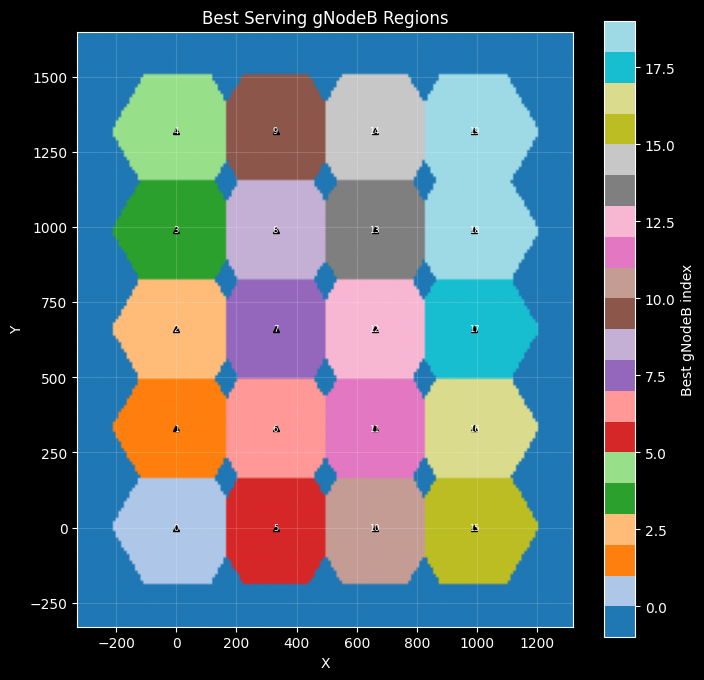

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(
    best_gnb_map,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    aspect='equal',
    cmap='tab20'
)
plt.colorbar(label="Best gNodeB index")

for i, g in enumerate(gnbs):
    plt.plot(g.x, g.y, 'k^', markersize=5)
    plt.text(g.x, g.y, str(i), color='white', fontsize=6, ha='center', va='center')

plt.title("Best Serving gNodeB Regions")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(alpha=0.15)
plt.show()

In [ ]:
env = MultiGNBWrapper(
    gnb_list=gnbs,
    handover_hysteresis=1.0,
    handover_ttt=2,
    verbose=False
)

obs, info = env.reset()
print("Obs shape:", obs.shape)
print(info)

Obs shape: (264,)
{'step': 0, 'n_gnbs': 20, 'n_tracked_ues': 0, 'n_connected_ues': 0, 'n_disconnected_ues': 0, 'ue_per_gnb': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'handover_count_total': 0, 'handover_count_step': 0, 'per_gnb_rewards': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'interference_model': 'same_carrier => interference, different_carrier => no_interference'}


In [ ]:
ue_ids = []

xmin = min(g.x for g in gnbs)
xmax = max(g.x for g in gnbs)
ymin = min(g.y for g in gnbs)
ymax = max(g.y for g in gnbs)

for _ in range(N_UES):
    x = rng.uniform(xmin, xmax)
    y = rng.uniform(ymin, ymax)
    vx = rng.uniform(-30, 30)
    vy = rng.uniform(-30, 30)
    ue_ids.append(env.add_ue(x, y, vx, vy, slice_type="eMBB"))

print("UE count:", len(ue_ids))
print(env.get_ue_radio_metrics(ue_ids[0]))

UE count: 30
{'ue_id': 0, 'x': 766.2164880704037, 'y': 579.319540472709, 'slice_type': 'eMBB', 'serving_gnb': 12, 'serving_power_dbm': np.float64(-55.783432562246645), 'interference_dbm': -inf, 'noise_dbm': np.float64(-114.44727494896694), 'sinr_db': np.float64(58.663842386720276), 'connected': True}


In [ ]:
steps = 100

trajectories = {uid: [] for uid in ue_ids}
serving = {uid: [] for uid in ue_ids}

for t in range(steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for uid in ue_ids:
        ue = env.get_ue(uid)
        trajectories[uid].append((ue.x, ue.y))
        serving[uid].append(ue.serving_gnb)

print("Total handovers:", len(env.handover_log))
print("Connected UEs:", env._count_connected_ues())
print("Disconnected UEs:", env._count_disconnected_ues())

Total handovers: 11
Connected UEs: 30
Disconnected UEs: 0


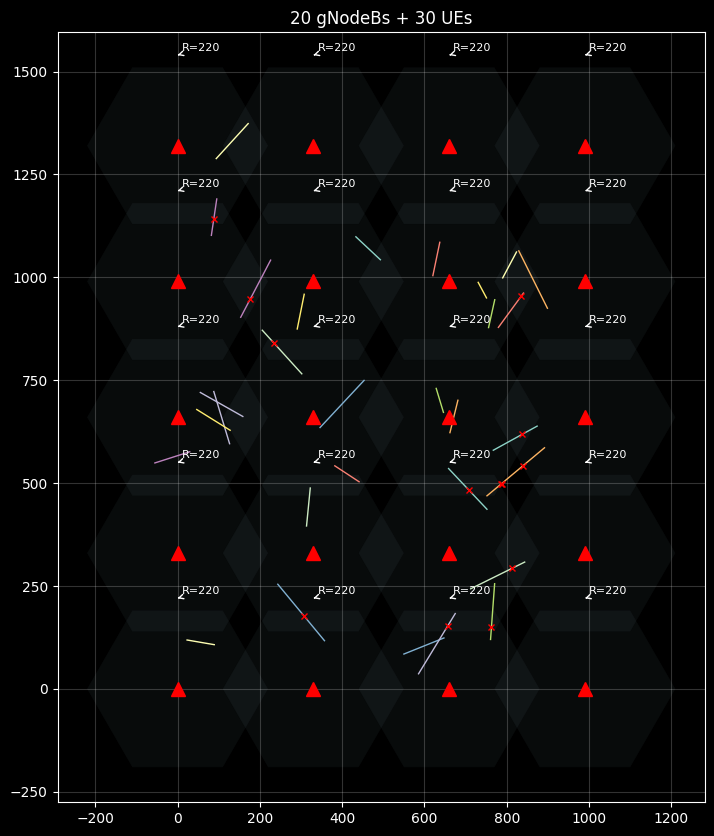

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

for g in gnbs:
    g.visualize_coverage(ax=ax, alpha=0.05, edge_color='black', linewidth=0.5)
    ax.plot(g.x, g.y, 'k.', markersize=3)

for uid in ue_ids:
    traj = np.array(trajectories[uid])
    ax.plot(traj[:, 0], traj[:, 1], linewidth=1)

    s = serving[uid]
    for t in range(1, len(s)):
        if s[t] != s[t - 1]:
            ax.plot(traj[t, 0], traj[t, 1], 'rx', markersize=5)

ax.set_title("20 gNodeBs + 30 UEs")
ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.show()

In [ ]:
for uid in ue_ids[:5]:
    print(env.get_ue_radio_metrics(uid))

{'ue_id': 0, 'x': 873.7958640438134, 'y': 638.5299491905176, 'slice_type': 'eMBB', 'serving_gnb': 17, 'serving_power_dbm': np.float64(-54.73157258639442), 'interference_dbm': -inf, 'noise_dbm': np.float64(-114.44727494896694), 'sinr_db': np.float64(59.7157023625725), 'connected': True}
{'ue_id': 1, 'x': 171.57748500587937, 'y': 1373.640795743602, 'slice_type': 'eMBB', 'serving_gnb': 4, 'serving_power_dbm': np.float64(-58.37555950325287), 'interference_dbm': -inf, 'noise_dbm': np.float64(-114.44727494896694), 'sinr_db': np.float64(56.07171544571406), 'connected': True}
{'ue_id': 2, 'x': 88.07190361856436, 'y': 722.5389346767339, 'slice_type': 'eMBB', 'serving_gnb': 2, 'serving_power_dbm': np.float64(-53.95124266763456), 'interference_dbm': -inf, 'noise_dbm': np.float64(-114.44727494896694), 'sinr_db': np.float64(60.49603228133236), 'connected': True}
{'ue_id': 3, 'x': 620.450728528056, 'y': 1004.2169460529328, 'slice_type': 'eMBB', 'serving_gnb': 13, 'serving_power_dbm': np.float64(-45.

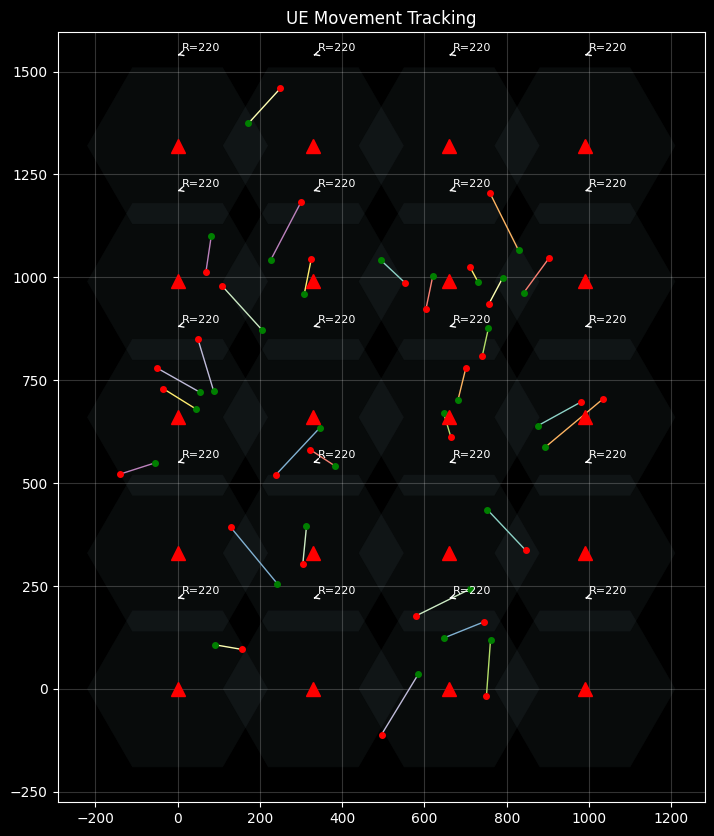

In [ ]:
# Track UE movement over time
steps = 100

# Store positions of each UE at every step
ue_paths = {ue_id: [] for ue_id in ue_ids}

for t in range(steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for ue_id in ue_ids:
        ue = env.get_ue(ue_id)
        ue_paths[ue_id].append((ue.x, ue.y))

# Plot trajectories
fig, ax = plt.subplots(figsize=(10, 10))

# Plot gNB coverage
for g in gnbs:
    g.visualize_coverage(ax=ax, alpha=0.05, edge_color='black', linewidth=0.5)
    ax.plot(g.x, g.y, 'k.', markersize=3)

# Plot UE trajectories
for ue_id, path in ue_paths.items():
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], linewidth=1, label=f'UE {ue_id}')
    ax.plot(path[0, 0], path[0, 1], 'go', markersize=4)   # start
    ax.plot(path[-1, 0], path[-1, 1], 'ro', markersize=4) # end

ax.set_title("UE Movement Tracking")
ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.show()

 UE moves →
    find best gNB →
        compare with current →
            if better enough (hysteresis) →
                wait TTT steps →
                    handover

In [ ]:
# Show full handover history
print("Total handovers:", len(env.handover_log))

for i, event in enumerate(env.handover_log):
    print(
        f"{i:03d} | step={event['step']:3d} | "
        f"UE={event['ue_id']:2d} | "
        f"{event['from_gnb']} -> {event['to_gnb']} | "
        f"pos=({event['x']:.2f}, {event['y']:.2f})"
    )

Total handovers: 21
000 | step= 20 | UE=12 | 11 -> 10 | pos=(656.76, 153.44)
001 | step= 23 | UE=18 | 16 -> 11 | pos=(813.07, 293.06)
002 | step= 24 | UE= 5 | 11 -> 12 | pos=(785.81, 497.46)
003 | step= 31 | UE= 7 | 3 -> 8 | pos=(176.24, 946.51)
004 | step= 43 | UE=24 | 5 -> 6 | pos=(307.77, 176.67)
005 | step= 52 | UE=20 | 12 -> 11 | pos=(707.60, 483.48)
006 | step= 55 | UE=27 | 4 -> 3 | pos=(88.00, 1141.43)
007 | step= 65 | UE= 0 | 12 -> 17 | pos=(837.22, 618.40)
008 | step= 69 | UE=28 | 7 -> 8 | pos=(235.02, 839.46)
009 | step= 77 | UE= 6 | 11 -> 10 | pos=(762.81, 150.17)
010 | step= 91 | UE=13 | 13 -> 18 | pos=(835.68, 955.08)
011 | step=106 | UE= 1 | 4 -> 9 | pos=(177.06, 1379.65)
012 | step=111 | UE=25 | 18 -> 13 | pos=(820.83, 1081.26)
013 | step=121 | UE=10 | 8 -> 13 | pos=(506.08, 1030.46)
014 | step=154 | UE=28 | 8 -> 3 | pos=(152.60, 930.40)
015 | step=171 | UE=25 | 13 -> 14 | pos=(778.68, 1165.71)
016 | step=178 | UE=24 | 6 -> 1 | pos=(153.06, 363.74)
017 | step=188 | UE= 7